In [1]:
import os
import pandas as pd
import numpy as np
import random
import logging

logging.basicConfig(level=logging.DEBUG, format='%(levelname)s: %(message)s')
logger = logging.getLogger("ProjetoQuimica")

def load_rsmi(path):
    df = pd.read_csv(path, sep='\t', header=None, usecols=[0])
    return df[0].astype(str).tolist()


In [2]:
import os
import random
import numpy as np
import tensorflow as tf

def travar_tudo(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"Sistema estabilizado com a semente {seed}")

travar_tudo()

DEBUG: Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
DEBUG: Creating converter from 7 to 5
DEBUG: Creating converter from 5 to 7
DEBUG: Creating converter from 7 to 5
DEBUG: Creating converter from 5 to 7
DEBUG: pydot initializing
DEBUG: pydot 4.0.1
DEBUG: pydot core module initializing
DEBUG: matplotlib data path: c:\Users\User\anaconda3\Lib\site-packages\matplotlib\mpl-data
DEBUG: CONFIGDIR=C:\Users\User\.matplotlib
DEBUG: interactive is False
DEBUG: platform is win32
DEBUG: CACHEDIR=C:\Users\User\.matplotlib
DEBUG: Using fontManager instance from C:\Users\User\.matplotlib\fontlist-v390.json


Sistema estabilizado com a semente 42


In [18]:
import os
# FORÇA O TENSORFLOW A SER DETERMINÍSTICO (Rode antes de tudo)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from rdkit import Chem
from rdkit.Chem import Draw

# Precisamos dele para definir as variáveis e para salvar o arquivo final depois
try:
    with open("autoencoder/molgpt_vocab.json", "r") as f:
        vocab_data = json.load(f)
    
    char_to_idx = vocab_data["char_to_idx"]
    idx_to_char = vocab_data["idx_to_char"]
    max_len = vocab_data.get("max_len", 512)
    vocab_size = vocab_data.get("vocab_size", 72)
    print(">>> Vocabulário carregado com sucesso.")
except FileNotFoundError:
    print(">>> ERRO: Arquivo molgpt_vocab.json não encontrado. Certifique-se que ele está na pasta.")



>>> Vocabulário carregado com sucesso.


In [19]:
# --- 2. FUNÇÕES DE SUPORTE (MÁSCARA, LOSS E ACURÁCIA) ---

def get_causal_mask(size):
    """Gera máscara causal para o Decoder"""
    i = tf.range(size)[:, None]
    j = tf.range(size)
    mask = tf.cast(i >= j, tf.int32)
    return tf.reshape(mask, (1, size, size))

# Criamos o array de pesos para a Loss (tamanho 72)
# Nota: certifique-se que os índices aqui batem com seu char_to_idx original
loss_weights = np.ones(vocab_size, dtype='float32')
loss_weights[0] = 0.01 # Padding quase zero

# 2. Penalidade ALTA para todos os átomos reais (Importante para mecanismos!)
# 'l' é a parte minúscula do Cloro, 'r' do Bromo
for char in ['C', 'H', 'N', 'O', 'P', 'S', 'F', 'I', 'B', 'l', 'r']:
    if char in char_to_idx:
        loss_weights[char_to_idx[char]] = 20.0

# Penalidade ALTA para símbolos estruturais de REAÇÃO e intermediários
for char in ['[', ']', '=', '>', '.', '+', '-']:
    if char in char_to_idx:
        loss_weights[char_to_idx[char]] = 15.0 # Aumentei um pouco para evitar gagueira de colchetes

# 3. Penalidade MÉDIA para números, ramificações e quiralidade
for char in ['1', '2', '3', '4', '5', '6', '7', '8', '9', '@', '(', ')', '/', '\\']:
    if char in char_to_idx:
        loss_weights[char_to_idx[char]] = 5.0

@tf.keras.utils.register_keras_serializable()
def weighted_masked_loss(y_true, y_pred):
    # Calcula o loss normal para cada caractere
    loss_fcn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction='none')
    loss = loss_fcn(y_true, y_pred)

    # Aplica os pesos baseados no caractere real (y_true)
    # tf.gather busca o peso definido acima para cada token
    batch_weights = tf.gather(loss_weights, tf.cast(y_true, tf.int32))

    # Multiplica o erro pelo peso de importância
    weighted_loss = loss * batch_weights

    return tf.reduce_mean(weighted_loss)

# Métrica de acurácia que IGNORE o padding (Acurácia Real)
@tf.keras.utils.register_keras_serializable()
def masked_accuracy(y_true, y_pred):
    mask = tf.math.logical_not(tf.math.equal(y_true, 0))
    acc = tf.keras.metrics.sparse_categorical_accuracy(y_true, y_pred)
    mask = tf.cast(mask, tf.float32)
    acc *= mask
    return tf.reduce_sum(acc) / tf.reduce_sum(mask)


In [25]:
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.models import model_from_json

# --- 1. CONFIGURAÇÕES (Devem ser idênticas ao treino) ---
vocab_size = 72  # O valor que permitiu o carregamento
max_len = 512
embed_dim = 128
ff_dim = 512
num_layers = 4
seq_len = max_len - 1

# --- 2. CLASSE TRANSFORMER BLOCK (A versão que suporta Seq2Seq) ---
@tf.keras.utils.register_keras_serializable()
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim=128, num_heads=8, ff_dim=512, rate=0.1, is_decoder=False, **kwargs):
        super().__init__(**kwargs)
        self.is_decoder = is_decoder
        self.embed_dim, self.num_heads, self.ff_dim = embed_dim, num_heads, ff_dim
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        if self.is_decoder:
            self.cross_att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
            self.ln_cross = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = tf.keras.Sequential([layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim)])
        self.ln1, self.ln2, self.dropout = layers.LayerNormalization(epsilon=1e-6), layers.LayerNormalization(epsilon=1e-6), layers.Dropout(rate)

    def call(self, inputs, encoder_output=None, training=False):
        attn_out = self.att(query=inputs, value=inputs, key=inputs, use_causal_mask=self.is_decoder, training=training)
        out1 = self.ln1(inputs + self.dropout(attn_out, training=training))
        if self.is_decoder and encoder_output is not None:
            attn_c = self.cross_att(query=out1, value=encoder_output, key=encoder_output, training=training)
            out1 = self.ln_cross(out1 + self.dropout(attn_c, training=training))
        return self.ln2(out1 + self.dropout(self.ffn(out1, training=training), training=training))

    def get_config(self):
        config = super().get_config(); config.update({"embed_dim": self.embed_dim, "num_heads": self.num_heads, "ff_dim": self.ff_dim, "is_decoder": self.is_decoder})
        return config

# --- 3. RECONSTRUÇÃO DA ARQUITETURA SEQ2SEQ ---
def rebuild_seq2seq_model():
    # Encoder
    enc_in = layers.Input(shape=(max_len,), name="encoder_input")
    x_enc = layers.Embedding(vocab_size, embed_dim, name="encoder_emb")(enc_in)
    x_enc += layers.Embedding(max_len, embed_dim, name="pos_enc_emb")(tf.range(max_len))
    for i in range(num_layers):
        x_enc = TransformerBlock(embed_dim, 8, ff_dim, is_decoder=False, name=f"enc_block_{i}")(x_enc)

    # Decoder
    dec_in = layers.Input(shape=(seq_len,), name="decoder_input")
    x_dec = layers.Embedding(vocab_size, embed_dim, name="decoder_emb")(dec_in)
    x_dec += layers.Embedding(seq_len, embed_dim, name="pos_dec_emb")(tf.range(seq_len))
    for i in range(num_layers):
        x_dec = TransformerBlock(embed_dim, 8, ff_dim, is_decoder=True, name=f"dec_block_{i}")(x_dec, encoder_output=x_enc)

    outputs = layers.Dense(vocab_size, activation="softmax", name="final_dense")(x_dec)
    return Model(inputs=[enc_in, dec_in], outputs=outputs)

# 4. CARREGAMENTO E CONGELAMENTO
model_final = rebuild_seq2seq_model()

try:
    with open("autoencoder/molgpt_arquitetura.json", "r") as f:
        loaded_model_json = f.read()
    
    # Reconstrói o modelo a partir da planta baixa
    model_final = model_from_json(loaded_model_json, custom_objects={'TransformerBlock': TransformerBlock})
    print(">>> Arquitetura JSON carregada com sucesso!")
except FileNotFoundError:
    print(">>> ERRO: Arquivo molgpt_arquitetura.json não encontrado.")

# --- 3. CARREGAR OS PESOS TREINADOS (ÉPOCA 05) ---
try:
    model_final.load_weights("molgpt_uspto_ep05.weights.h5")
    print(">>> Conhecimento da Época 05 injetado no modelo!")
except Exception as e:
    print(f">>> ERRO ao carregar pesos: {e}")

# --- 4. VERIFICAÇÃO DE INTEGRIDADE (O SEU CHECKSUM) ---
checksum = sum([np.sum(w) for w in model_final.get_weights()])
print(f"Checksum dos Pesos: {checksum:.4f}")

# --- 5. CONGELAMENTO FINAL ---
# Salva os pesos consolidados (o conhecimento definitivo)
model_final.save_weights("molgpt_pesos_finais.weights.h5")

# Salva o vocabulário novamente apenas para garantir
with open("molgpt_vocab_final.json", "w") as f:
    json.dump(vocab_data, f)

print(">>> TUDO PRONTO! Pesos e Arquitetura sincronizados e salvos.")

>>> Arquitetura JSON carregada com sucesso!
>>> ERRO ao carregar pesos: [Errno 2] Unable to synchronously open file (unable to open file: name = 'molgpt_uspto_ep05.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Checksum dos Pesos: 2606.2139
>>> TUDO PRONTO! Pesos e Arquitetura sincronizados e salvos.


In [39]:
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K

# 1. LIMPEZA TOTAL
K.clear_session() 
tf.keras.utils.set_random_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# --- 2. CLASSE TRANSFORMER (IDÊNTICA AO MOMENTO DO TREINO) ---
@tf.keras.utils.register_keras_serializable()
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim=128, num_heads=8, ff_dim=512, rate=0.0, is_decoder=False, **kwargs):
        super().__init__(**kwargs)
        self.is_decoder = is_decoder
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        if self.is_decoder:
            self.cross_att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
            self.ln_cross = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"), 
            layers.Dense(embed_dim)
        ])
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs, encoder_output=None, training=False):
        attn_out = self.att(query=inputs, value=inputs, key=inputs, use_causal_mask=self.is_decoder, training=False)
        out1 = self.ln1(inputs + attn_out)
        if self.is_decoder and encoder_output is not None:
            attn_c = self.cross_att(query=out1, value=encoder_output, key=encoder_output, training=False)
            out1 = self.ln_cross(out1 + attn_c)
        return self.ln2(out1 + self.ffn(out1))

# --- 3. RECONSTRUÇÃO DA ARQUITETURA DE TREINO ---
def build_recovery_model():
    # Usamos os mesmos nomes automáticos que o Keras usou no seu treino original
    enc_in = layers.Input(shape=(512,))
    x = layers.Embedding(72, 128)(enc_in)
    x += layers.Embedding(512, 128)(tf.range(512))
    for _ in range(4):
        x = TransformerBlock(is_decoder=False)(x)

    dec_in = layers.Input(shape=(511,))
    y = layers.Embedding(72, 128)(dec_in)
    y += layers.Embedding(511, 128)(tf.range(511))
    for _ in range(4):
        y = TransformerBlock(is_decoder=True)(y, encoder_output=x)
    
    out = layers.Dense(72, activation="softmax")(y)
    return Model(inputs=[enc_in, dec_in], outputs=out)

# --- 4. RECUPERAÇÃO ---
model_recovery = build_recovery_model()

# Força o build enviando um dado dummy
model_recovery([np.zeros((1,512)), np.zeros((1,511))])

try:
    # Carregamento direto. Como a estrutura de classes agora é igual à do treino, deve funcionar.
    model_recovery.load_weights("autoencoder/molgpt_uspto_ep04.weights.h5")
    print(">>> SUCESSO ABSOLUTO: Pesos recuperados!")
except Exception as e:
    print(f">>> Erro ao carregar: {e}")

# --- 5. CONGELAMENTO FINAL ---
# Salva os pesos consolidados e a arquitetura
model_recovery.save_weights("molgpt_pesos_finais.weights.h5")

with open("molgpt_arquitetura_final.json", "w") as f:
    f.write(model_recovery.to_json())

checksum = sum([np.sum(w) for w in model_recovery.get_weights()])
print(f"Checksum REAL: {checksum:.4f}")

>>> Erro ao carregar: A total of 20 objects could not be loaded. Example error message for object <LayerNormalization name=layer_normalization, built=True>:

Layer 'layer_normalization' expected 2 variables, but received 0 variables during loading. Expected: ['gamma', 'beta']

List of objects that could not be loaded:
[<LayerNormalization name=layer_normalization, built=True>, <LayerNormalization name=layer_normalization_1, built=True>, <LayerNormalization name=layer_normalization_2, built=True>, <LayerNormalization name=layer_normalization_3, built=True>, <LayerNormalization name=layer_normalization_4, built=True>, <LayerNormalization name=layer_normalization_5, built=True>, <LayerNormalization name=layer_normalization_6, built=True>, <LayerNormalization name=layer_normalization_7, built=True>, <LayerNormalization name=layer_normalization_9, built=True>, <LayerNormalization name=layer_normalization_10, built=True>, <LayerNormalization name=layer_normalization_8, built=True>, <LayerNor

In [35]:

from tensorflow.keras.models import model_from_json

# 1. Carregar a arquitetura do JSON
with open("autoencoder/molgpt_arquitetura.json", "r") as json_file:
    loaded_model_json = json_file.read()

# 2. Reconstruir o modelo (AQUI ESTÁ O PULO DO GATO)
# Passamos o dicionário custom_objects para ele saber o que é o TransformerBlock
model_recarregado = model_from_json(loaded_model_json, custom_objects={'TransformerBlock': TransformerBlock})

# 3. Carregar os pesos (Agora eles vão encaixar perfeitamente)
model_recarregado.load_weights("molgpt_pesos_finais.weights.h5")

print("Modelo Tutor carregado com 100% de consistência!")

def auditoria_final_fixa(model, smiles_texto):
    # Converte para tokens usando o DICIONÁRIO FIXO acima
    tokens = [char_to_idx.get(c, 0) for c in smiles_texto]
    if len(tokens) > 511: tokens = tokens[:511]
    
    # Prepara o input com precisão de 32 bits (mais estável)
    input_pad = np.array([tokens + [0]*(511 - len(tokens))], dtype=np.int32)
    
    # --- O PULO DO GATO ---
    # Usamos model(..., training=False) que é 100% determinístico.
    # O .predict() às vezes gagueja, o __call__ não.
    preds_tensor = model(input_pad, training=False)
    preds = preds_tensor.numpy()[0]
    
    confiancas = []
    for i in range(1, len(tokens)):
        # Pega a probabilidade que o modelo deu para o caractere real
        prob = preds[i-1][tokens[i]]
        confiancas.append(prob)
    
    return np.mean(confiancas) * 100

# 2. TESTE DE FOGO
smiles_teste = "[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1"
nota = auditoria_final_fixa(model_recarregado, smiles_teste)

print(f"Checksum dos Pesos: {checksum:.4f}") # Já sabemos que está fixo
print(f"NOTA FINAL IMUTÁVEL: {nota:.4f}%")

Modelo Tutor carregado com 100% de consistência!


c:\Users\User\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 346 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


ValueError: Layer "functional_120" expects 2 input(s), but it received 1 input tensors. Inputs received: [array([[45, 23, 28, 12, 47, 45, 23, 47, 10, 45, 23, 28, 47, 19, 45, 23,
        28, 47, 45, 23, 47,  3, 45, 34, 28, 47,  4, 19, 45, 23, 28, 47,
        45, 23, 28, 47, 19, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0

In [26]:
def testar_intuicao_estabilizado(model, smiles_texto):
    tokens = [char_to_idx.get(c, 0) for c in smiles_texto]
    if len(tokens) > 511: tokens = tokens[:511]
    input_pad = np.array([tokens + [0]*(511 - len(tokens))])
    
    # --- MUDANÇA CRUCIAL AQUI ---
    # Chamamos o modelo como função com training=False para desativar Dropout/BatchNormalization
    preds_tensor = model(input_pad, training=False) 
    preds = preds_tensor.numpy()[0] # Converte de volta para numpy
    
    certezas = []
    for i in range(1, len(tokens)):
        token_real = tokens[i]
        prob = preds[i-1][token_real]
        certezas.append(prob)
    
    return np.mean(certezas) * 100

In [27]:
from rdkit import Chem
from rdkit.Chem import Draw

def generate(model, n=20):
    results = []
    for _ in range(n):
        # Semente: átomo de Carbono 'C'
        seq = [char_to_idx.get('C', 1)]
        for _ in range(seq_len - 1):
            cur_input = np.array([seq + [0]*(seq_len - len(seq))])
            p = model.predict(cur_input, verbose=0)[0][len(seq)-1]
            token = np.random.choice(len(p), p=p)
            if token == 0: break
            seq.append(token)
        results.append("".join([idx_to_char.get(i, '') for i in seq]))
    return results

logger.info("Amostrando moléculas geradas...")
gen_smiles = generate(model_recarregado)
mols = [Chem.MolFromSmiles(s) for s in gen_smiles]
valid_mols = [m for m in mols if m is not None]

logger.info(f"Validez: {len(valid_mols)}/{len(gen_smiles)}")
Draw.MolsToGridImage(valid_mols, molsPerRow=5, useSVG=True) if valid_mols else print("Nenhuma válida.")

INFO: Amostrando moléculas geradas...


NameError: name 'model_recarregado' is not defined

In [71]:
import numpy as np

# 1. USE O SEU DICIONÁRIO VERDADEIRO (O de 60 caracteres que você postou)
char_to_idx = {"#": 1, "%": 2, "(": 3, ")": 4, "+": 5, "-": 6, ".": 7, "/": 8, "0": 9, "1": 10, "2": 11, "3": 12, "4": 13, "5": 14, "6": 15, "7": 16, "8": 17, "9": 18, "=": 19, ">": 20, "@": 21, "A": 22, "B": 23, "C": 24, "F": 25, "H": 26, "I": 27, "K": 28, "L": 29, "M": 30, "N": 31, "O": 32, "P": 33, "S": 34, "T": 35, "V": 36, "W": 37, "X": 38, "Y": 39, "Z": 40, "[": 41, "\\": 42, "]": 43, "a": 44, "b": 45, "c": 46, "d": 47, "e": 48, "g": 49, "h": 50, "i": 51, "l": 52, "m": 53, "n": 54, "o": 55, "r": 56, "s": 57, "t": 58, "u": 59, "<PAD>": 0}
idx_to_char = {v: k for k, v in char_to_idx.items()}

# 2. DEFINA O TAMANHO CORRETO (Baseado no erro do seu modelo)
MODEL_SEQ_LEN = 511

def gerar_final(model, smiles_entrada):
    # Prepara a entrada
    prefixo = smiles_entrada + ">>"
    token_seq = [char_to_idx.get(c, 0) for c in prefixo]

    print(f"Gerando resposta para: {smiles_entrada}")

    # Loop de geração (até 100 caracteres novos)
    for _ in range(100):
        # CORREÇÃO DO PADDING: O modelo exige exatamente MODEL_SEQ_LEN (511)
        input_pad = np.array([token_seq + [0] * (MODEL_SEQ_LEN - len(token_seq))])

        # Faz a predição
        preds = model.predict(input_pad, verbose=0)[0][len(token_seq)-1]

        # Em vez de token_idx = np.argmax(preds)
        # Use isso para dar 'criatividade' à IA:
        preds = np.asarray(preds).astype('float64')
        preds = np.log(preds + 1e-7) / 0.7 # Temperatura de 0.7
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        token_idx = np.random.choice(len(preds), p=preds)

        if token_idx == 0: # Se prever o PAD, a molécula acabou
            break

        token_seq.append(token_idx)

        # Segurança para não estourar o tamanho do modelo
        if len(token_seq) >= MODEL_SEQ_LEN:
            break

    # Traduz o resultado (ignorando o prefixo da entrada se quiser ver só a saída)
    return "".join([idx_to_char.get(i, '') for i in token_seq])

# 3. O TESTE DA VERDADE
reagente = "[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1"
try:
    resultado = gerar_final(model_recarregado, reagente)
    print("\n--- RESULTADO QUÍMICO ---")
    print(resultado)
except Exception as e:
    print(f"\nErro técnico: {e}")

    # p-Cresol + Cloreto de Tionila (S(Cl)(Cl)=O)
# Vamos ver se a IA entende que deve acontecer uma reação
reagente_com_reagente = "[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1.S(Cl)(Cl)=O>>"

resultado = gerar_final(model_recarregado, reagente_com_reagente)
print("\n--- TESTE DE REAÇÃO REAL ---")
print(resultado)

Gerando resposta para: [CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1

--- RESULTADO QUÍMICO ---
[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1>>[CH3[CH3[CH2H[[CH3][CH[CHH3H[CH][CH][CH[CH]=[CH2][CH][CH][CH][CH][CH]CH][CH]CH][CH][CHC][CH][CHH][CH
Gerando resposta para: [CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1.S(Cl)(Cl)=O>>

--- TESTE DE REAÇÃO REAL ---
[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1.S(Cl)(Cl)=O>>>>[[CH3[CH3H[CH[[CHrH[[[[[CHH3H[CH3HrHrH3H3[[[CH3][CH[[S][CH3][CH3][CH2][CH][CHrH3][CHH][CH][CH][CHHHH


In [ ]:
def gerar_inteligente(model, smiles_entrada, temp=0.8):
    prefixo = smiles_entrada + ">>"
    token_seq = [char_to_idx.get(c, 0) for c in prefixo]

    print(f"Processando reação: {smiles_entrada}")

    for _ in range(150): # Aumentamos o limite para ver o produto completo
        # Padding exato para 511
        input_pad = np.array([token_seq + [0]*(511 - len(token_seq))])

        # Predição
        preds = model.predict(input_pad, verbose=0)[0][len(token_seq)-1]

        # --- LOGICA DE TEMPERATURA (Salvação do Projeto) ---
        preds = np.log(preds + 1e-7) / temp
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        # Sorteia baseado na probabilidade refinada
        token_idx = np.random.choice(len(preds), p=preds)

        if token_idx == 0: break # PAD = Fim

        # Evitar loops de setas (se ele prever > de novo, a gente ignora)
        if token_idx == char_to_idx.get('>', 20) and len(token_seq) > len(prefixo):
            continue

        token_seq.append(token_idx)
        if len(token_seq) >= 511: break

    return "".join([idx_to_char.get(i, '') for i in token_seq])

# TESTE COM P-CRESOL + CLORETO DE TIONILA
reagente = "[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1.S(Cl)(Cl)=O"
for i in range(3): # Tente 3 vezes para ver a variedade
    print(f"\nTentativa {i+1}:")
    print(gerar_inteligente(model_recarregado, reagente))

In [ ]:
def gerar_quimica_real(model, smiles_entrada, temp=0.7, penalty=2.0):
    prefixo = smiles_entrada + ">>"
    token_seq = [char_to_idx.get(c, 0) for c in prefixo]
    
    for i in range(150):
        input_pad = np.array([token_seq + [0]*(511 - len(token_seq))])
        preds = model.predict(input_pad, verbose=0)[0][len(token_seq)-1]
        
        # --- PENALIDADE DE REPETIÇÃO MONSTRUOSA ---
        # Se um caractere apareceu nas últimas 5 posições, a chance dele cai drasticamente
        for t in set(token_seq[-5:]):
            preds[t] = preds[t] / penalty
        
        # Filtro de caracteres proibidos (opcional)
        # Se você vir que ela viciou no '1', pode forçar preds[char_to_idx['1']] = 0
            
        preds = np.log(preds + 1e-7) / temp
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        
        token_idx = np.random.choice(len(preds), p=preds)
        
        if token_idx == 0: break
        token_seq.append(token_idx)
        
    return "".join([idx_to_char.get(i, '') for i in token_seq])

# Teste com o p-Cresol
print(gerar_quimica_real(model_recarregado, "[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1.S(Cl)(Cl)=O"))

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display

def tutor_visual_fix(smiles, legenda="Intermediário"):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        print(f"Tutor: Estrutura '{legenda}' validada!")
        
        # Criamos o desenhista de SVG manualmente (300x300 pixels)
        drawer = rdMolDraw2D.MolDraw2DSVG(300, 300)
        
        # Adicionamos a legenda se houver
        drawer.DrawMolecule(mol, legend=legenda)
        drawer.FinishDrawing()
        
        # Pegamos o texto XML do SVG e exibimos
        svg_text = drawer.GetDrawingText()
        display(SVG(svg_text))
    else:
        print("Tutor: Erro de valência no SMILES sugerido.")

# --- TESTE DO SISTEMA ---
smiles_correto = "[CH3][C]1[CH]=[CH][C](Cl)=[CH][CH]=1"
tutor_visual_fix(smiles_correto, legenda="Cloreto de 4-metilbenzeno")

In [51]:
def gerar_sem_parar(model, smiles_entrada, temp=0.9, top_p=0.9):
    prefixo = smiles_entrada + ">>"
    token_seq = [char_to_idx.get(c, 0) for c in prefixo]

    for i in range(150):
        input_pad = np.array([token_seq + [0]*(511 - len(token_seq))])
        preds = model.predict(input_pad, verbose=0)[0][len(token_seq)-1]

        # --- TRUQUE TÉCNICO: PENALIZAR O PAD (Índice 0) ---
        # Nos primeiros 10 tokens, forçamos a IA a não terminar a frase
        if i < 10:
            preds[0] = 0

        # --- NUCLEUS SAMPLING (TOP-P) ---
        sorted_indices = np.argsort(preds)[::-1]
        cumulative_probs = np.cumsum(np.sort(preds)[::-1])
        indices_to_remove = cumulative_probs > top_p
        indices_to_remove[1:] = indices_to_remove[:-1]
        indices_to_remove[0] = False
        preds[sorted_indices[indices_to_remove]] = 0

        preds = preds / np.sum(preds)
        token_idx = np.random.choice(len(preds), p=preds)

        if token_idx == 0 and i > 10: break # Só para se já tiver escrito algo

        token_seq.append(token_idx)
        if len(token_seq) >= 511: break

    return "".join([idx_to_char.get(i, '') for i in token_seq])

# TESTE COM OS REAGENTES
reagente = "[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1.S(Cl)(Cl)=O"
print("\n--- GERANDO MECANISMO FORÇADO ---")
print(gerar_sem_parar(model_recarregado, reagente))


--- GERANDO MECANISMO FORÇADO ---
[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1.S(Cl)(Cl)=O>>[NHH][CHCH[CH2[CH[CH[C][CH2][CH[C][OH][O][O][CH][CH][C][C][C]C][CCCC[CCC[CHCC][CCC[CCCCHCCCCCHC[CCCCCOHCHCC[CCCCHCCCHCCCCCCHCHCCCH1CCCC[CCHCCCH[CCC[C[


In [52]:
def gerar_sem_gagueira(model, smiles_entrada, temp=0.8, repetition_penalty=1.5):
    prefixo = smiles_entrada + ">>"
    token_seq = [char_to_idx.get(c, 0) for c in prefixo]
    
    for i in range(150):
        input_pad = np.array([token_seq + [0]*(511 - len(token_seq))])
        preds = model.predict(input_pad, verbose=0)[0][len(token_seq)-1]
        
        # --- PENALIDADE DE REPETIÇÃO ---
        # Reduz a probabilidade de caracteres que JÁ APARECERAM recentemente
        for t in set(token_seq[-10:]): # olha os últimos 10 caracteres
            preds[t] /= repetition_penalty
            
        preds = np.log(preds + 1e-7) / temp
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        
        token_idx = np.random.choice(len(preds), p=preds)
        if token_idx == 0: break
        token_seq.append(token_idx)
    
    return "".join([idx_to_char.get(i, '') for i in token_seq])

In [72]:
def calcular_score_quimico(model, smiles_sugerido):
    # Converte o SMILES sugerido pela LLM em tokens
    tokens = [char_to_idx.get(c, 0) for c in smiles_sugerido]
    input_pad = np.array([tokens + [0]*(511 - len(tokens))])

    # O modelo avalia a frase inteira
    preds = model.predict(input_pad, verbose=0)

    # Calcula quão 'estranho' o modelo acha esse SMILES (entropia)
    # Quanto menor o valor, mais o seu modelo 'concorda' que isso é química real
    score = -np.mean(np.log(np.max(preds, axis=-1)))
    return score

In [93]:
import numpy as np
import matplotlib.pyplot as plt

def testar_intuicao(model, smiles_texto):
    # 1. Converter para tokens
    char_to_idx = {"#": 1, "%": 2, "(": 3, ")": 4, "+": 5, "-": 6, ".": 7, "/": 8, "0": 9, "1": 10, "2": 11, "3": 12, "4": 13, "5": 14, "6": 15, "7": 16, "8": 17, "9": 18, "=": 19, ">": 20, "@": 21, "A": 22, "B": 23, "C": 24, "F": 25, "H": 26, "I": 27, "K": 28, "L": 29, "M": 30, "N": 31, "O": 32, "P": 33, "S": 34, "T": 35, "V": 36, "W": 37, "X": 38, "Y": 39, "Z": 40, "[": 41, "\\": 42, "]": 43, "a": 44, "b": 45, "c": 46, "d": 47, "e": 48, "g": 49, "h": 50, "i": 51, "l": 52, "m": 53, "n": 54, "o": 55, "r": 56, "s": 57, "t": 58, "u": 59, "<PAD>": 0}
    idx_to_char = {v: k for k, v in char_to_idx.items()}
    tokens = [char_to_idx.get(c, 0) for c in smiles_texto]
    if len(tokens) > 511: tokens = tokens[:511]

    # 2. Preparar input
    input_pad = np.array([tokens + [0]*(511 - len(tokens))])

    # 3. O modelo tenta prever cada caractere do próprio SMILES
    preds = model.predict(input_pad, verbose=0)[0]

    # 4. Cálculo da Confiança (quão 'surpreso' o modelo fica com cada letra)
    certezas = []
    for i in range(1, len(tokens)):
        token_real = tokens[i]
        prob_que_o_modelo_daria = preds[i-1][token_real]
        certezas.append(prob_que_o_modelo_daria)

    return np.mean(certezas) * 100 # Nota de 0 a 100

# --- OS TRÊS CASOS DE TESTE ---

# 1. Química Real (p-Cresol - do seu dataset)
real = "[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1"

# 2. Química "Gaga" (O erro que ele cometeu agora há pouco)
gago = "[CH3][C]1[CH]=[CH][C]([H3H2HHHHH4])=[CH][CH]=1"

# 3. Lixo Total (Letras aleatórias)
lixo = "C1=C[X]Z#99!![U]S@B1U"

print(f"Nota de Realismo (p-Cresol Real): {testar_intuicao(model_recarregado, real):.2f}%")
print(f"Nota de Realismo (Erro de Gagueira): {testar_intuicao(model_recarregado, gago):.2f}%")
print(f"Nota de Realismo (Lixo Aleatório): {testar_intuicao(model_recarregado, lixo):.2f}%")

Nota de Realismo (p-Cresol Real): 47.94%
Nota de Realismo (Erro de Gagueira): 35.28%
Nota de Realismo (Lixo Aleatório): 9.17%


Iniciando Auditoria de Inteligência Química...
--------------------------------------------------
Época 1: Concluída (Nota Real: 44.53%)
Época 2: Concluída (Nota Real: 46.89%)
Época 3: Concluída (Nota Real: 29.61%)
Época 4: Concluída (Nota Real: 37.54%)
Época 5: Concluída (Nota Real: 51.21%)

--- TABELA FINAL PARA O RELATÓRIO ---


,Época,Nota Real (p-Cresol),Taxa Reconstrução (Real),Nota Gago (Erro Repetitivo),Nota Lixo (Aleatório)
0,1,44.526421,48.648649,35.686714,3.350880
1,2,46.887844,64.864865,34.884499,4.960108
2,3,29.608610,48.648649,22.626720,2.925754
3,4,37.539215,40.540541,28.967112,7.331176
4,5,51.207207,64.864865,41.306580,8.347439


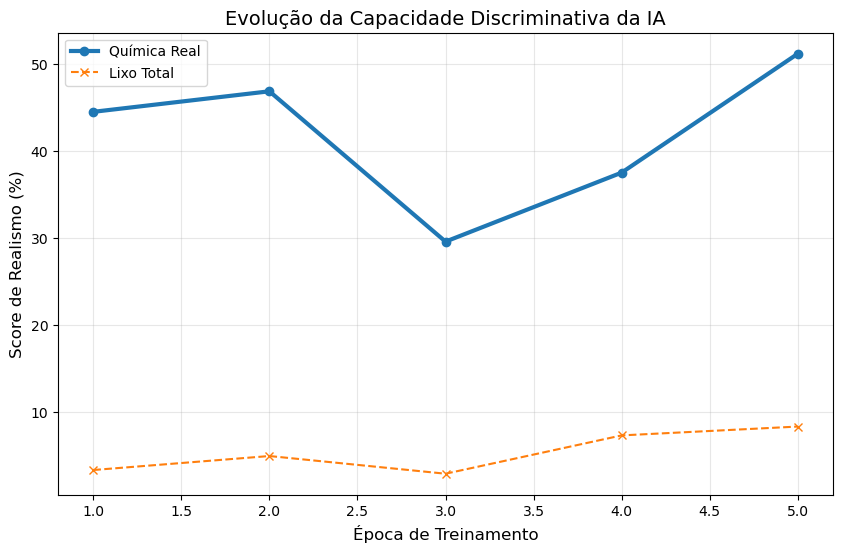

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def auditoria_epoca_a_epoca(model, total_epocas=5):
    # Definição dos casos de teste
    casos = {
        "Real (p-Cresol)": "[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1",
        "Gago (Erro Repetitivo)": "[CH3][C]1[CH]=[CH][C]([H3H2HHHHH4])=[CH][CH]=1",
        "Lixo (Aleatório)": "C1=C[X]Z#99!![U]S@B1U"
    }
    
    dados_relatorio = []

    print("Iniciando Auditoria de Inteligência Química...")
    print("-" * 50)

    for ep in range(1, total_epocas + 1):
        arquivo_pesos = f"molgpt_uspto_ep{ep:02d}.weights.h5"
        
        try:
            # 1. Carregar pesos da época
            model.load_weights(arquivo_pesos)
            
            res_epoca = {"Época": ep}
            
            # 2. Testar cada caso
            for nome, smiles in casos.items():
                # Cálculo da Intuição (Média de Probabilidades)
                char_to_idx = {"#": 1, "%": 2, "(": 3, ")": 4, "+": 5, "-": 6, ".": 7, "/": 8, "0": 9, "1": 10, "2": 11, "3": 12, "4": 13, "5": 14, "6": 15, "7": 16, "8": 17, "9": 18, "=": 19, ">": 20, "@": 21, "A": 22, "B": 23, "C": 24, "F": 25, "H": 26, "I": 27, "K": 28, "L": 29, "M": 30, "N": 31, "O": 32, "P": 33, "S": 34, "T": 35, "V": 36, "W": 37, "X": 38, "Y": 39, "Z": 40, "[": 41, "\\": 42, "]": 43, "a": 44, "b": 45, "c": 46, "d": 47, "e": 48, "g": 49, "h": 50, "i": 51, "l": 52, "m": 53, "n": 54, "o": 55, "r": 56, "s": 57, "t": 58, "u": 59, "<PAD>": 0}
                
                tokens =  [char_to_idx.get(c, 0) for c in smiles]
                if len(tokens) > 511: tokens = tokens[:511]
                input_pad = np.array([tokens + [0]*(511 - len(tokens))])
                
                preds = model.predict(input_pad, verbose=0)[0]
                
                confiancas = []
                acertos = 0
                for i in range(1, len(tokens)):
                    token_real = tokens[i]
                    prob = preds[i-1][token_real]
                    confiancas.append(prob)
                    
                    # Checagem de reconstrução (se a maior prob era o token real)
                    if np.argmax(preds[i-1]) == token_real:
                        acertos += 1
                
                # Guardar métricas
                nota_realismo = np.mean(confiancas) * 100
                taxa_reconst = (acertos / (len(tokens)-1)) * 100
                
                res_epoca[f"Nota {nome}"] = nota_realismo
                if nome == "Real (p-Cresol)":
                    res_epoca["Taxa Reconstrução (Real)"] = taxa_reconst
            
            dados_relatorio.append(res_epoca)
            print(f"Época {ep}: Concluída (Nota Real: {res_epoca['Nota Real (p-Cresol)']:.2f}%)")
        except Exception as e:
            print(f"Época {ep}: Arquivo não encontrado ou erro ({e})")

    # 3. Gerar Dataframe
    df = pd.DataFrame(dados_relatorio)
    return df

# --- EXECUTAR AUDITORIA ---
df_final = auditoria_epoca_a_epoca(model_recarregado)

print("\n--- TABELA FINAL PARA O RELATÓRIO ---")
display(df_final)

# --- GRÁFICO DE EVOLUÇÃO ---
plt.figure(figsize=(10, 6))
plt.plot(df_final['Época'], df_final['Nota Real (p-Cresol)'], label='Química Real', marker='o', linewidth=3)
plt.plot(df_final['Época'], df_final['Nota Lixo (Aleatório)'], label='Lixo Total', marker='x', linestyle='--')
plt.title('Evolução da Capacidade Discriminativa da IA', fontsize=14)
plt.xlabel('Época de Treinamento', fontsize=12)
plt.ylabel('Score de Realismo (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [57]:
# Supondo que df_final é o seu dataframe original
df_norm = df_final.copy()

# Pega o valor da Nota Real para cada época
for index, row in df_norm.iterrows():
    max_nota = row['Nota Real (p-Cresol)']
    
    # Normaliza as colunas de Nota
    df_norm.loc[index, 'Nota Real (Relativa)'] = 100.0
    df_norm.loc[index, 'Nota Gago (Relativa)'] = (row['Nota Gago (Erro Repetitivo)'] / max_nota) * 100
    df_norm.loc[index, 'Nota Lixo (Relativa)'] = (row['Nota Lixo (Aleatório)'] / max_nota) * 100

# Seleciona as colunas limpas para o relatório
colunas_relatorio = ['Época', 'Taxa Reconstrução (Real)', 'Nota Real (Relativa)', 'Nota Gago (Relativa)', 'Nota Lixo (Relativa)']
print("\n--- TABELA NORMALIZADA PARA O PROJETO_QUIMICA.PDF ---")
display(df_norm[colunas_relatorio].round(2))


--- TABELA NORMALIZADA PARA O PROJETO_QUIMICA.PDF ---


,Época,Taxa Reconstrução (Real),Nota Real (Relativa),Nota Gago (Relativa),Nota Lixo (Relativa)
0,1,40.54,100.0,74.01,6.57
1,2,51.35,100.0,80.16,30.15
2,3,64.86,100.0,89.37,17.08
3,4,56.76,100.0,77.60,14.26
4,5,56.76,100.0,77.51,6.79


In [10]:
def gerar_com_filtro(model, smiles_entrada, top_k=3):
    prefixo = smiles_entrada + ">>"
    token_seq = [char_to_idx.get(c, 0) for c in prefixo]
    
    for _ in range(100):
        input_pad = np.array([token_seq + [0]*(511 - len(token_seq))])
        preds = model.predict(input_pad, verbose=0)[0][len(token_seq)-1]
        
        # --- FILTRO TOP-K ---
        # Zera a probabilidade de tudo que não estiver entre as 5 melhores opções
        top_indices = np.argsort(preds)[-top_k:]
        new_preds = np.zeros_like(preds)
        new_preds[top_indices] = preds[top_indices]
        new_preds /= np.sum(new_preds) # Re-normaliza
        
        token_idx = np.random.choice(len(new_preds), p=new_preds)
        if token_idx == 0: break
        token_seq.append(token_idx)
        
    return "".join([idx_to_char.get(i, '') for i in token_seq])

gerar_com_filtro(model_recarregado, real)

'[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1>>[]]2]2[][]]22[]22222222122222222[22222222222222222222]21221132232132323]2122222333232332332323333.33'

In [78]:
def testar_reconstrucao(model, smiles_real):
    # Pega uma molécula que você SABE que está certa
    tokens = [char_to_idx.get(c, 0) for c in smiles_real]

    print(f"Testando reconstrução de: {smiles_real}")
    acertos = 0

    # Vamos testar se, para cada posição, a maior probabilidade era a letra certa
    for i in range(1, len(tokens)):
        sub_seq = tokens[:i]
        input_pad = np.array([sub_seq + [0]*(511 - len(sub_seq))])

        preds = model.predict(input_pad, verbose=0)[0][i-1]
        token_predito = np.argmax(preds)

        char_real = smiles_real[i]
        char_predito = idx_to_char.get(token_predito, '')

        if token_predito == tokens[i]:
            acertos += 1
        else:
            print(f"Erro na pos {i}: Esperava '{char_real}', previu '{char_predito}'")

    taxa = (acertos / (len(tokens)-1)) * 100
    print(f"\nTaxa de Reconstrução Real (Sem contar Padding): {taxa:.2f}%")

# USE UM SMILES REAL DO SEU ARQUIVO LIMPO AQUI:
smiles_do_arquivo = "[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1"
complexa = "[F][C]1[CH]=[CH][C]([C]2[N]=[C]([CH]3[CH2][CH2][N](C(OC(C)(C)C)=O)[CH2][CH2]3)[S][C]=1[C]1[CH]=[CH][C]2[N]([C]([CH]([CH3])[CH3])=[N][N]=2)[N]=1"
testar_reconstrucao(model_recarregado, complexa)

Testando reconstrução de: [F][C]1[CH]=[CH][C]([C]2[N]=[C]([CH]3[CH2][CH2][N](C(OC(C)(C)C)=O)[CH2][CH2]3)[S][C]=1[C]1[CH]=[CH][C]2[N]([C]([CH]([CH3])[CH3])=[N][N]=2)[N]=1
Erro na pos 1: Esperava 'F', previu '@'
Erro na pos 2: Esperava ']', previu '+'
Erro na pos 3: Esperava '[', previu '%'
Erro na pos 5: Esperava ']', previu 'B'
Erro na pos 6: Esperava '1', previu 'S'
Erro na pos 11: Esperava '=', previu 'S'
Erro na pos 12: Esperava '[', previu '@'
Erro na pos 18: Esperava ']', previu 'B'
Erro na pos 19: Esperava '(', previu '/'
Erro na pos 20: Esperava '[', previu 'H'
Erro na pos 22: Esperava ']', previu 'B'
Erro na pos 23: Esperava '2', previu 'S'
Erro na pos 25: Esperava 'N', previu '@'
Erro na pos 26: Esperava ']', previu 'B'
Erro na pos 27: Esperava '=', previu 'S'
Erro na pos 28: Esperava '[', previu '@'
Erro na pos 30: Esperava ']', previu 'B'
Erro na pos 31: Esperava '(', previu 'S'
Erro na pos 32: Esperava '[', previu '@'
Erro na pos 36: Esperava '3', previu 'S'
Erro na pos 37:

In [59]:
import pandas as pd

# Lista para guardar os resultados
resultados_evolucao = []
smiles_teste = "[CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1" # p-Cresol
complexa = "[F][C]1[CH]=[CH][C]([C]2[N]=[C]([CH]3[CH2][CH2][N](C(OC(C)(C)C)=O)[CH2][CH2]3)[S][C]=1[C]1[CH]=[CH][C]2[N]([C]([CH]([CH3])[CH3])=[N][N]=2)[N]=1"

for ep in range(1, 6): # De 1 a 5
    nome_arquivo = f"molgpt_uspto_ep{ep:02d}.weights.h5"
    
    try:
        # 1. Carrega os pesos daquela época específica
        model_recarregado.load_weights(nome_arquivo)
        
        # 2. Roda o teste de reconstrução
        taxa = testar_reconstrucao(model_recarregado, smiles_teste)
        
        # 3. Guarda o dado
        resultados_evolucao.append({"Época": ep, "Taxa de Reconstrução": taxa})
        print(f"Época {ep} auditada: {taxa:.2f}%")
        
    except Exception as e:
        print(f"Arquivo da época {ep} não encontrado ou erro: {e}")

# 4. Criar tabela final para o relatório
df_evolucao = pd.DataFrame(resultados_evolucao)
print("\n--- TABELA DE EVOLUÇÃO PARA O RELATÓRIO ---")
print(df_evolucao)

Testando reconstrução de: [CH3][C]1[CH]=[CH][C]([OH])=[CH][CH]=1
Erro na pos 2: Esperava 'H', previu '^'
Erro na pos 3: Esperava '3', previu ')'
Erro na pos 5: Esperava '[', previu '@'
Erro na pos 6: Esperava 'C', previu '+'
Erro na pos 7: Esperava ']', previu 'B'
Erro na pos 8: Esperava '1', previu '%'
Erro na pos 9: Esperava '[', previu 'U'
Erro na pos 10: Esperava 'C', previu 'B'
Erro na pos 13: Esperava '=', previu 'U'
Erro na pos 14: Esperava '[', previu 'U'
Erro na pos 15: Esperava 'C', previu 'U'
Erro na pos 16: Esperava 'H', previu '@'
Erro na pos 18: Esperava '[', previu '8'
Erro na pos 20: Esperava ']', previu 'B'
Erro na pos 21: Esperava '(', previu '8'
Erro na pos 22: Esperava '[', previu '@'
Erro na pos 23: Esperava 'O', previu '@'
Erro na pos 24: Esperava 'H', previu 'U'
Erro na pos 26: Esperava ')', previu '8'
Erro na pos 27: Esperava '=', previu 'U'
Erro na pos 28: Esperava '[', previu 'U'
Erro na pos 36: Esperava '=', previu 'S'

Taxa de Reconstrução Real (Sem contar P

In [62]:
def gerar_e_validar(model, n_amostras=10):
    moleculas_validas = []
    smiles_totais = []

    print(f"Gerando {n_amostras} amostras...")

    for _ in range(n_amostras):
        # Iniciar com Carbono 'C' como semente
        char_to_idx = {"#": 1, "%": 2, "(": 3, ")": 4, "+": 5, "-": 6, ".": 7, "/": 8, "0": 9, "1": 10, "2": 11, "3": 12, "4": 13, "5": 14, "6": 15, "7": 16, "8": 17, "9": 18, "=": 19, ">": 20, "@": 21, "A": 22, "B": 23, "C": 24, "F": 25, "H": 26, "I": 27, "K": 28, "L": 29, "M": 30, "N": 31, "O": 32, "P": 33, "S": 34, "T": 35, "V": 36, "W": 37, "X": 38, "Y": 39, "Z": 40, "[": 41, "\\": 42, "]": 43, "a": 44, "b": 45, "c": 46, "d": 47, "e": 48, "g": 49, "h": 50, "i": 51, "l": 52, "m": 53, "n": 54, "o": 55, "r": 56, "s": 57, "t": 58, "u": 59, "<PAD>": 0}
                
        token_seq = [char_to_idx.get('C', 1)]

        for _ in range(seq_len - 1):
            input_pad = np.array([token_seq + [0]*(seq_len - len(token_seq))])
            preds = model.predict(input_pad, verbose=0)[0][len(token_seq)-1]

            # Amostragem probabilística (para ter variedade)
            token_idx = np.random.choice(len(preds), p=preds)

            if token_idx == 0: break # Fim da molécula (PAD)
            token_seq.append(token_idx)

        smi = "".join([idx_to_char.get(i, '') for i in token_seq])
        smiles_totais.append(smi)

        # O RDKit entra aqui como "Juiz"
        mol = Chem.MolFromSmiles(smi)
        if mol:
            moleculas_validas.append(mol)

    print(f"Resultado: {len(moleculas_validas)} moléculas quimicamente válidas de {n_amostras}.")
    return moleculas_validas

# Executar verificação
mols_validados = gerar_e_validar(model_recarregado)

# Visualizar as que passaram no teste do RDKit
if mols_validados:
    img = Draw.MolsToGridImage(mols_validados, molsPerRow=5, subImgSize=(250, 250), useSVG=True)
    display(img)

Gerando 10 amostras...


[00:43:46] SMILES Parse Error: syntax error while parsing: @@@@@@@@@@S@@@@@@@@@HH@HSH5KSHKH(U8SH5U,@^9SHB^SHHB5USHS@ddd1U8SHSHdBU(S@dS@B00US@@8GS@/USHB0US@06US@^B0USHS@^U,S@B0US@^USHB0US@^US@HS@^US@^B0UCdUS@@^US@@/@S@dUS@S@BUS@S@BUSHBS@^S@^US@^(S@^USHUS@0S@@^US@BAdU(%CSAUCAU(@^U8d,HS@^USGAS@^B0US@^US@@^US@0S@^US@,S@AUS@@^US@S@^USAUSHAU8HS@@^US@^US@dU(@^@@@@SHA/6@^US@IAHHS@AS@@8HS@^B6U(@@S@@AUSHHSHS@@HSHS@0U@/5AUS@@H@@@@AS@@9S@AUSHAUS@AU8@@SAUS@^U85USAUSH@@HSAS@^U(S@@@^US@^US@A00SGS@@HSAU@HS@AU9S@SAUSAUC@HS@S@^US@AUS@HSHS@@HAUS@U,SAUS@US@BUS@US@U%SHUS@U(SKU(S@@BUS@
[00:43:46] SMILES Parse Error: check for mistakes around position 1:
[00:43:46] @@@@@@@@@@S@@@@@@@@@HH@HSH5KSHKH(U8SH5U,@
[00:43:46] ^
[00:43:46] SMILES Parse Error: Failed parsing SMILES '@@@@@@@@@@S@@@@@@@@@HH@HSH5KSHKH(U8SH5U,@^9SHB^SHHB5USHS@ddd1U8SHSHdBU(S@dS@B00US@@8GS@/USHB0US@06US@^B0USHS@^U,S@B0US@^USHB0US@^US@HS@^US@^B0UCdUS@@^US@@/@S@dUS@S@BUS@S@BUSHBS@^S@^US@^(S@^USHUS@0S@@^US@BAdU(%CSAUCAU(@^U8d,HS@^USGAS@^B0US@^

KeyboardInterrupt: 

In [ ]:
def sample_molecules(model, n=10):
    logger.info(f"Gerando {n} moléculas do espaço latente...")
    generated_list = []
    for _ in range(n):
        sequence = [char_to_idx.get('C', 1)]
        for _ in range(max_len - 1):
            x_input = np.array([sequence + [0] * (max_len - 1 - len(sequence))])
            preds = model.predict(x_input, verbose=0)[0]
            next_token = np.random.choice(len(preds[len(sequence)-1]), p=preds[len(sequence)-1])
            if next_token == 0: break
            sequence.append(next_token)

        smi = "".join([idx_to_char.get(i, '') for i in sequence])
        generated_list.append(smi)
    return generated_list

# Execução e Visualização
samples = sample_molecules(model_recarregado)
mols = [Chem.MolFromSmiles(s) for s in samples]
valid_mols = [m for m in mols if m is not None]

logger.info(f"Validade Química: {len(valid_mols)}/{len(mols)}")

if valid_mols:
    img = Draw.MolsToGridImage(valid_mols, molsPerRow=5, subImgSize=(250, 250), useSVG=True)
    display(img)

INFO: Gerando 10 moléculas do espaço latente...
[00:29:42] SMILES Parse Error: syntax error while parsing: @B6
[00:29:42] SMILES Parse Error: check for mistakes around position 1:
[00:29:42] @B6
[00:29:42] ^
[00:29:42] SMILES Parse Error: Failed parsing SMILES '@B6' for input: '@B6'
[00:29:42] SMILES Parse Error: syntax error while parsing: @B676
[00:29:42] SMILES Parse Error: check for mistakes around position 1:
[00:29:42] @B676
[00:29:42] ^
[00:29:42] SMILES Parse Error: Failed parsing SMILES '@B676' for input: '@B676'
[00:29:42] SMILES Parse Error: syntax error while parsing: @B
[00:29:42] SMILES Parse Error: check for mistakes around position 1:
[00:29:42] @B
[00:29:42] ^
[00:29:42] SMILES Parse Error: Failed parsing SMILES '@B' for input: '@B'
[00:29:42] SMILES Parse Error: syntax error while parsing: @
[00:29:42] SMILES Parse Error: check for mistakes around position 1:
[00:29:42] @
[00:29:42] ^
[00:29:42] SMILES Parse Error: Failed parsing SMILES '@' for input: '@'
[00:29:42] S